<a href="https://colab.research.google.com/github/Prerana241/SmartSwipe/blob/main/Week_0/SS_assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SmartSwipe — Assignment 1

**Dataset:** `transactions.csv`  
Explore the dataset on your own, find out about the different columns in the dataset.

---


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
## Q1 — Python Fundamentals `[10 pts]`

You are given the list `amounts` below.

1. Write a function `summarise(amounts, threshold)` that returns a **dict** with keys:
   - `above_threshold`: list of values strictly greater than `threshold`, sorted descending
   - `mean`: arithmetic mean (no libraries)
   - `count_above`: integer count
2. Call it with `threshold=500` and print the result.


In [2]:
# your code here
def summarise(amounts, threshold):

    above_threshold = [x for x in amounts if x > threshold]
    above_threshold.sort(reverse = True)


    total_sum = sum(amounts)
    count_all = len(amounts)
    mean = total_sum / count_all if count_all > 0 else 0.0


    count_above = len(above_threshold)

    return {
        "above_threshold": above_threshold,
        "mean": mean,
        "count_above": count_above
    }


df = pd.read_csv('transactions.csv')


amounts_list = df['amount'].tolist()

result = summarise(amounts_list, threshold = 500)


print(result)

{'above_threshold': [14205.88, 14011.64, 13184.18, 13086.34, 12304.94, 12250.73, 12199.01, 11818.92, 11772.79, 11662.54, 11471.08, 11371.61, 11234.88, 11199.06, 11195.5, 11101.87, 11073.38, 11069.15, 11007.74, 10905.49, 10864.93, 10713.45, 10491.16, 10380.89, 10359.9, 10312.18, 10252.55, 10151.58, 10150.55, 10095.57, 9796.81, 9794.37, 9783.26, 9764.67, 9716.4, 9612.35, 9608.31, 9600.26, 9593.46, 9568.04, 9492.12, 9468.63, 9421.41, 9420.5, 9416.27, 9376.75, 9323.98, 9311.32, 9244.25, 9211.58, 9126.68, 9093.21, 9051.72, 9026.74, 9016.71, 8991.0, 8891.44, 8880.77, 8858.52, 8828.05, 8807.32, 8786.62, 8769.03, 8713.76, 8698.26, 8687.37, 8678.88, 8671.19, 8657.93, 8651.19, 8649.46, 8643.98, 8628.76, 8604.56, 8600.0, 8591.48, 8535.93, 8504.49, 8465.53, 8427.74, 8426.91, 8375.23, 8358.33, 8317.36, 8290.01, 8255.59, 8217.94, 8211.15, 8191.41, 8187.97, 8173.21, 8154.55, 8151.36, 8089.08, 8081.51, 8077.92, 8054.42, 8021.97, 8015.36, 8010.49, 7982.2, 7973.71, 7950.58, 7946.57, 7941.33, 7901.92, 78

---
## Q2 — NumPy `[15 pts]`

Load **only** the `amount` column into a NumPy array. Then:

1. Print mean, median, std, 10th and 90th percentiles.
2. Create a boolean mask for **outlier** transactions: those where `|amount − mean| > 2 × std`.
3. Normalise the array to `[0, 1]` using min-max scaling and store it as `amounts_norm`.
4. Using `np.histogram`, compute a 10-bin histogram of `amounts_norm` and print bin edges + counts (no plot needed).


In [3]:
# your code here
df = pd.read_csv('transactions.csv', usecols = ['amount'])
amount_arr = df['amount'].to_numpy()

# Print mean, median, std, 10th and 90th percentiles
mean_val = np.mean(amount_arr)
median_val = np.median(amount_arr)
std_val = np.std(amount_arr)
p10 = np.percentile(amount_arr, 10)
p90 = np.percentile(amount_arr, 90)

print(f"Mean: {mean_val:.3f}")
print(f"Median: {median_val:.3f}")
print(f"Standard Deviation: {std_val:.3f}")
print(f"10th Percentile: {p10:.3f}")
print(f"90th Percentile: {p90:.3f}\n")

# Create a boolean mask for outlier transactions
outlier_mask = np.abs(amount_arr - mean_val) > 2 * std_val
print(f"Outlier transactions detected: {np.sum(outlier_mask)}\n")

# Normalise the array to [0, 1] using min-max scaling
min_val = np.min(amount_arr)
max_val = np.max(amount_arr)
amounts_norm = (amount_arr - min_val) / (max_val - min_val)

# Compute a 10-bin histogram of amounts_norm and print bin edges + counts
counts, bin_edges = np.histogram(amounts_norm, bins = 10)

print("10-Bin Histogram Summary:")
print("Counts per bin:", counts)
print("Bin edges:     ", bin_edges)

Mean: 1253.023
Median: 433.385
Standard Deviation: 1989.757
10th Percentile: 88.250
90th Percentile: 4024.015

Outlier transactions detected: 353

10-Bin Histogram Summary:
Counts per bin: [4020  479  191  187  141   81   47   18    8    4]
Bin edges:      [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


---
## Q3 — Pandas: Load & Explore `[15 pts]`

1. Load `smartswipe_transactions.csv` into a DataFrame `df`.
2. Print shape, dtypes, and count of missing values per column.
3. Parse `date` as `datetime` (in-place). Add a column `month` (integer, 1–12).
4. Print the statistical summary for numeric columns only.
5. How many unique `city` and `category` values exist? Print them.


In [4]:
# your code here
df = pd.read_csv('transactions.csv')

df.columns = df.columns.str.strip().str.lower()

# Print shapes, dtypes and missing values count
print(f"DataFrame Shape (Rows, Columns): {df.shape}\n")

print("Data Types (dtypes) per Column:")
print(df.dtypes)

print("\nCount of Missing Values per Column:")
print(df.isna().sum())

# Parse date as datetime, add column
df['datetime'] = pd.to_datetime(df['datetime'], errors = 'coerce')

df['month'] = df['datetime'].dt.month

# Statistical summary for numeric cols
print(df.describe(include = [np.number]))

# City and category values count
city_col = [col for col in df.columns if 'city' in col or 'loc' in col][0]
category_col = [col for col in df.columns if 'cat' in col or 'type' in col][0]

print(f"Number of unique values in '{city_col}': {df[city_col].nunique(dropna = False)}")
print(f"Unique values in '{city_col}':")
print(df[city_col].unique())

print(f"\nNumber of unique values in '{category_col}': {df[category_col].nunique(dropna = False)}")
print(f"Unique values in '{category_col}':")
print(df[category_col].unique())

DataFrame Shape (Rows, Columns): (5176, 9)

Data Types (dtypes) per Column:
txn_id       object
user_id      object
merchant     object
category     object
amount      float64
datetime     object
city         object
cashback    float64
status       object
dtype: object

Count of Missing Values per Column:
txn_id        0
user_id       0
merchant      0
category      0
amount        0
datetime      0
city          0
cashback    258
status        0
dtype: int64
             amount     cashback        month
count   5176.000000  4918.000000  5176.000000
mean    1253.022884    29.513211     3.455564
std     1989.949158    87.547840     1.678726
min       10.000000     0.000000     1.000000
25%      173.882500     1.070000     2.000000
50%      433.385000     6.565000     3.000000
75%     1251.317500    21.355000     5.000000
max    14205.880000  2440.530000     6.000000
Number of unique values in 'city': 9
Unique values in 'city':
['Delhi' 'Hyderabad' 'Chennai' 'Mumbai' 'Jaipur' 'Pune' 'Kan

---
## Q4 — Pandas: Filter & Transform `[20 pts]`

1. Filter to **approved** transactions only. What fraction of total transactions is this? Print as a percentage.
2. Add column `cashback_rate` = `cashback / amount`. Flag rows where this exceeds 0.10 as `suspicious` (boolean column).
3. Fill any missing `cashback` values with the **per-category median** cashback (do not use a global fill).
4. Create a `spend_tier` column: `low` (amount < 500), `mid` (500–2000), `high` (> 2000).
   Use `pd.cut` — do not write if-else chains.


In [8]:
# your code here
df = pd.read_csv('transactions.csv')

# Standardize column headers by wiping whitespace and forcing lowercase
df.columns = df.columns.str.strip().str.lower()

# Dynamically locate the key data columns using sub-string matching
status_col = [c for c in df.columns if 'status' in c or 'approve' in c][0]
amount_col = [c for c in df.columns if 'amount' in c or 'totalvalue' in c][0]
cashback_col = [c for c in df.columns if 'cashback' in c][0]
category_col = [c for c in df.columns if 'cat' in c or 'type' in c][0]

# Filter to Approved Transactions & Calculate Fraction

# Create a boolean mask identifying rows where the status is approved
approved_mask = df[status_col].astype(str).str.lower().str.contains('approved|approve')

# Keep track of global metrics
total_count = len(df)
approved_count = approved_mask.sum()

# Calculate the fraction of total transactions that are approved as a percentage
fraction_approved = (approved_count / total_count) * 100

print(f"Approved Transactions: {approved_count} out of {total_count}")
print(f"Percentage Approved: {fraction_approved:.2f}%\n")

# Isolate approved rows into a new DataFrame subset safely
df_approved = df[approved_mask].copy()

# Missing Value Imputation (Per-Category Median)

# Fill missing entries in the cashback column using the median value of its specific category
df_approved[cashback_col] = df_approved.groupby(category_col)[cashback_col].transform(
    lambda x: x.fillna(x.median())
)

# Cashback Rate Calculation & Suspicious Transaction Flagging

# Generate the transactional cashback rate attribute
df_approved['cashback_rate'] = df_approved[cashback_col] / df_approved[amount_col]

# Flag records as a boolean indicator if the rate exceeds 10% (0.10)
df_approved['suspicious'] = df_approved['cashback_rate'] > 0.10

suspicious_count = df_approved['suspicious'].sum()
print(f"Flagged {suspicious_count} suspicious transactions exceeding 10% cashback rate.\n")

# Categorical Spending Tier Segmentation via pd.cut

# Configure non-overlapping boundary edges mapping to the required brackets
# Brackets: low (< 500), mid (500–2000), high (> 2000)
bins = [-np.inf, 500, 2000, np.inf]
labels = ['low', 'mid', 'high']

# Segment continuous amount column data into distinct ordinal buckets
df_approved['spend_tier'] = pd.cut(df_approved[amount_col], bins = bins, labels = labels)

# Final Result
columns_to_show = [amount_col, category_col, cashback_col, 'cashback_rate', 'suspicious', 'spend_tier']
print(df_approved[columns_to_show].head())

Approved Transactions: 4605 out of 5176
Percentage Approved: 88.97%

Flagged 199 suspicious transactions exceeding 10% cashback rate.

    amount    category  cashback  cashback_rate  suspicious spend_tier
0  1152.59    Shopping     28.82       0.025005       False        mid
1    10.00  Healthcare      0.27       0.027000       False        low
2   926.70   Utilities     10.23       0.011039       False        mid
3   137.71   Groceries      3.26       0.023673       False        low
4  7001.18      Travel    180.27       0.025749       False       high


---
## Q5 — Pandas: Aggregation `[20 pts]`

1. For each `category`, compute: total spend, transaction count, avg transaction size, decline rate.
   Store as a clean DataFrame `category_stats` and print it sorted by total spend descending.
2. Find the **top-3 merchants** by total spend within each city. Output should be a DataFrame with columns `city`, `merchant`, `total_spend`.
3. Build a **month × category pivot table** of average transaction amounts. Print it.


In [7]:
# your code here
df = pd.read_csv('transactions.csv')

# Standardize column headers by clearing extra spaces and forcing lowercase
df.columns = df.columns.str.strip().str.lower()

# Dynamically find the date/time column to generate the 'month' feature if missing
if 'month' not in df.columns:
    date_col = [c for c in df.columns if 'date' in c or 'time' in c][0]
    df[date_col] = pd.to_datetime(df[date_col])
    df['month'] = df[date_col].dt.month

# Dynamically find the transaction status column
status_col = [c for c in df.columns if 'status' in c or 'approve' in c][0]

# Create a boolean helper column where True = 1 (Declined) and False = 0 (Approved)
# Taking the 'mean' of this column will mathematically yield the decline rate percentage
df['is_declined'] = df[status_col].astype(str).str.lower().str.contains('decline')

# Category Metrics (Total Spend, Count, Average, Decline Rate)

# Group data by category and apply multiple aggregation metrics simultaneously
category_stats = df.groupby('category').agg(
    total_spend = ('amount', 'sum'),
    transaction_count = ('amount', 'count'),
    avg_transaction_size = ('amount', 'mean'),
    decline_rate = ('is_declined', 'mean')
).reset_index()

# Sort the metric summary summary dataset by total spend in descending order
category_stats = category_stats.sort_values(by = 'total_spend', ascending = False)

# Output results for Part 1
print("Category Statistics (Sorted by Total Spend Descending)")
print(category_stats.to_string(index = False))

# Top-3 Merchants by Total Spend Within Each City

# Group data by city and merchant to find individual gross revenue totals
merchant_spend = df.groupby(['city', 'merchant'])['amount'].sum().reset_index()

# Sort rows hierarchically: City names A-Z, then Amounts within each city highest-to-lowest
top_merchants = merchant_spend.sort_values(by = ['city', 'amount'], ascending = [True, False])

# Group by city and use .head(3) to isolate only the top 3 highest revenue rows per city
top_3_merchants = top_merchants.groupby('city').head(3).copy()

# Rename the aggregated 'amount' column to match specification
top_3_merchants = top_3_merchants.rename(columns = {'amount': 'total_spend'})

# Output results for Part 2
print("Top 3 Merchants by Total Spend within Each City")
print(top_3_merchants.to_string(index = False))

# Month × Category Pivot Table of Average Transaction Amounts

# Restructure the data using a multi-dimensional matrix cross-tabulation table
pivot_table = df.pivot_table(
    values = 'amount',
    index = 'month',
    columns = 'category',
    aggfunc = 'mean'
)

# Output results
print(" Month x Category Pivot Table (Average Transaction Amount)")
print(pivot_table)

Category Statistics (Sorted by Total Spend Descending)
     category  total_spend  transaction_count  avg_transaction_size  decline_rate
       Travel   2213273.63                444           4984.850518      0.340090
  Electronics   1722710.26                384           4486.224635      0.377604
     Shopping   1031848.97                651           1585.021459      0.188940
   Healthcare    438697.56                420           1044.518000      0.061905
       Dining    371893.93                768            484.236888      0.045573
    Utilities    290547.44                390            744.993436      0.046154
    Groceries    195293.44                905            215.793856      0.049724
Entertainment    153913.21                527            292.055427      0.037951
         Fuel     67468.01                687             98.206710      0.011645
Top 3 Merchants by Total Spend within Each City
     city      merchant  total_spend
Bangalore   Apple Store     96407.84
Ban

---
## Q6 — Matplotlib: Visualisation `[20 pts]`

Produce a single `fig` with **3 subplots** (layout your choice):

1. **Bar chart** — Total spend per category. Sort bars descending. Label axes.
2. **Line chart** — Daily total spend over time. Use `date` on x-axis. Rotate tick labels 45°.
3. **Histogram** — Distribution of `amount` for approved vs declined transactions overlaid (use `alpha=0.6`). Add a legend.

Titles, axis labels, and `fig.tight_layout()` are required.


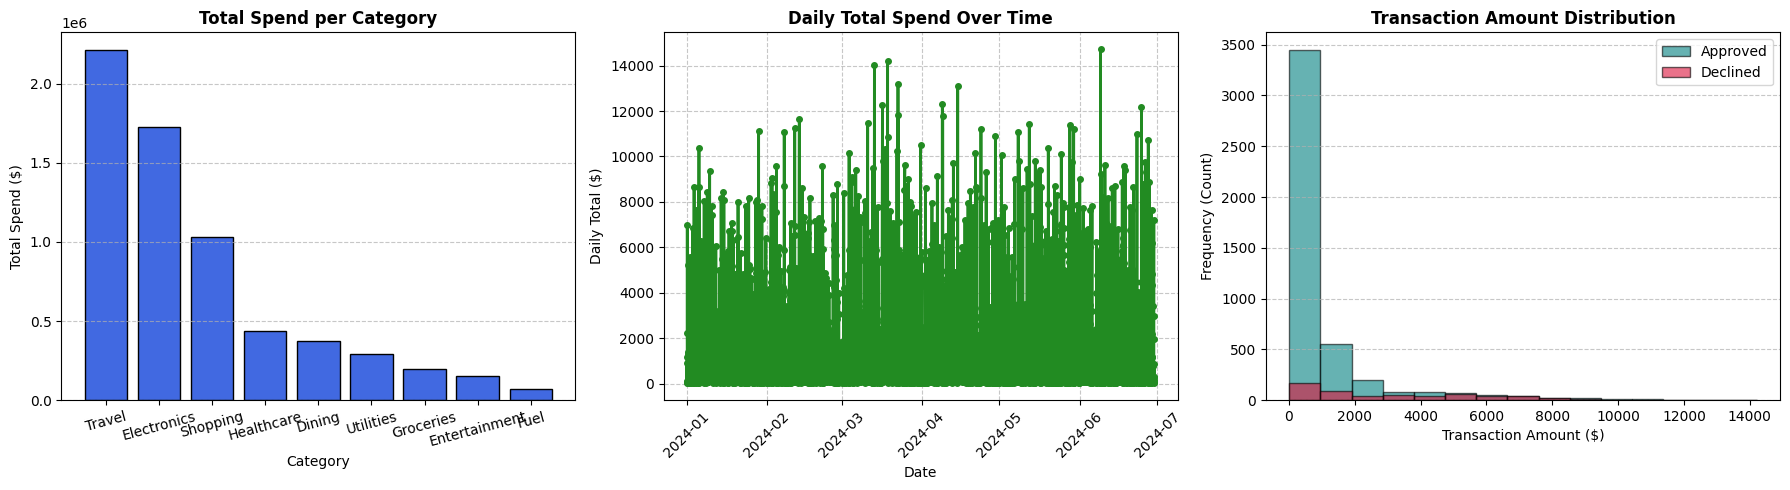

In [6]:
# your code here
df = pd.read_csv('transactions.csv')
df.columns = df.columns.str.strip().str.lower()

date_col = [c for c in df.columns if 'date' in c or 'time' in c][0]
status_col = [c for c in df.columns if 'status' in c or 'approve' in c][0]

df[date_col] = pd.to_datetime(df[date_col])

category_spend = df.groupby('category')['amount'].sum().sort_values(ascending=False)

daily_spend = df.groupby(date_col)['amount'].sum().sort_index()

approved_amounts = df[df[status_col].astype(str).str.lower().str.contains('approve')]['amount'].dropna()
declined_amounts = df[df[status_col].astype(str).str.lower().str.contains('decline')]['amount'].dropna()


fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (18, 5))

axes[0].bar(category_spend.index, category_spend.values, color = 'royalblue', edgecolor = 'black')
axes[0].set_title('Total Spend per Category', fontsize = 12, fontweight = 'bold')
axes[0].set_xlabel('Category', fontsize = 10)
axes[0].set_ylabel('Total Spend ($)', fontsize = 10)
axes[0].grid(axis = 'y', linestyle = '--', alpha = 0.7)
axes[0].tick_params(axis = 'x', rotation = 15)

axes[1].plot(daily_spend.index, daily_spend.values, color = 'forestgreen', marker = 'o', linewidth = 2, markersize = 4)
axes[1].set_title('Daily Total Spend Over Time', fontsize = 12, fontweight = 'bold')
axes[1].set_xlabel('Date', fontsize = 10)
axes[1].set_ylabel('Daily Total ($)', fontsize = 10)
axes[1].grid(True, linestyle = '--', alpha = 0.7)
axes[1].tick_params(axis = 'x', rotation = 45)

bins = np.histogram_bin_edges(df['amount'].dropna(), bins = 15)

axes[2].hist(approved_amounts, bins = bins, alpha = 0.6, label = 'Approved', color = 'teal', edgecolor = 'black')
axes[2].hist(declined_amounts, bins = bins, alpha = 0.6, label = 'Declined', color = 'crimson', edgecolor = 'black')
axes[2].set_title('Transaction Amount Distribution', fontsize = 12, fontweight = 'bold')
axes[2].set_xlabel('Transaction Amount ($)', fontsize = 10)
axes[2].set_ylabel('Frequency (Count)', fontsize = 10)
axes[2].grid(axis = 'y', linestyle = '--', alpha = 0.7)
axes[2].legend(fontsize = 10, loc = 'upper right')

plt.tight_layout()

plt.show()

---
## Q7 — Bonus `[30 pts]`

> This question is intentionally hard. Not compulsory.

**SmartSwipe Velocity Fraud Detector**

A transaction is part of a **velocity fraud event** if a single `user_id` has **≥ 3 transactions within any rolling 1-hour window**.

Date and Time are available in the CSV.

Tasks:

1. Write a function `flag_velocity_fraud(df, window='1h', min_txns=3)` that returns a boolean Series aligned to `df.index` — `True` if the transaction falls inside a fraud window for that user.
   - Must handle per-user sorted datetime correctly.
   - No row-wise Python loops over the full DataFrame.
2. Add column `velocity_fraud` using your function.
3. Compare flagged vs normal users on: avg spend, decline rate, top categories. Print a clean summary table.
4. Plot a **timeline scatter** (x = datetime, y = user_id, colour = velocity_fraud). Limit to 20 users for readability.



Velocity Fraud Summary

                Avg Spend  Decline Rate (%)                   Top Categories
velocity_fraud                                                              
False             1202.84               0.0        [Groceries, Dining, Fuel]
True              4026.14               0.0  [Travel, Electronics, Shopping]


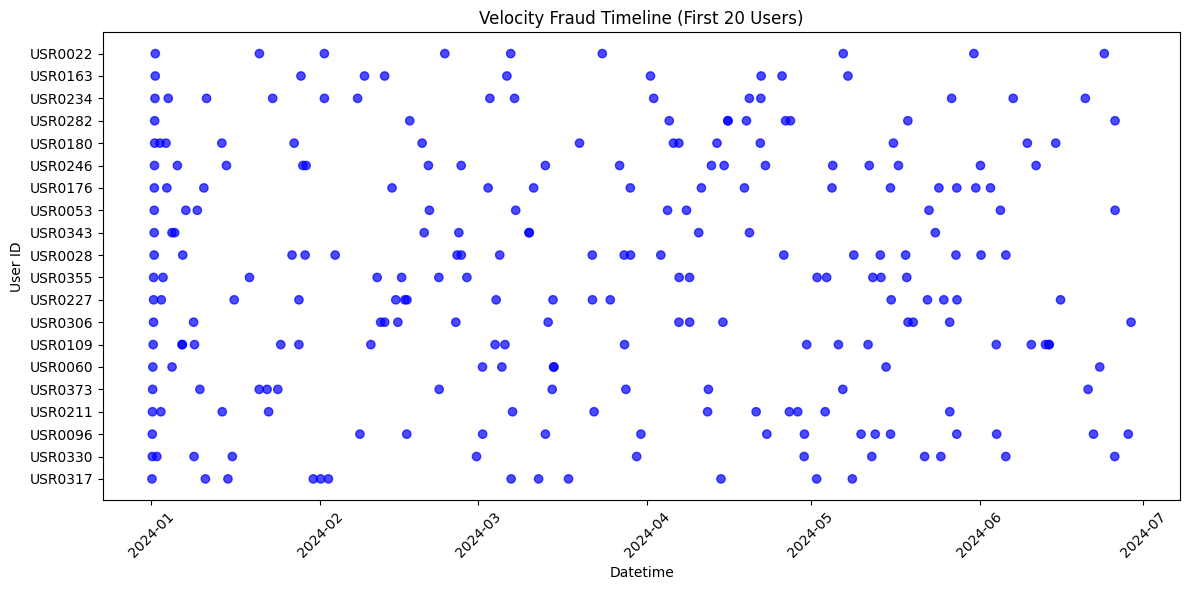

In [13]:
# your code here
df['datetime'] = pd.to_datetime(df['datetime'])

# Velocity Fraud Function
def flag_velocity_fraud(df, window = '1h', min_txns = 3):

    result = pd.Series(False, index = df.index)

    for user_id, group in df.groupby('user_id'):

        group = group.sort_values('datetime')

        counts = (
            group.set_index('datetime')
                 .rolling(window)
                 .count()['user_id']
        )

        fraud_times = counts[counts >= min_txns].index

        mask = group['datetime'].isin(fraud_times)

        result.loc[group.index] = mask

    return result

# Add Velocity Fraud Column

df['velocity_fraud'] = flag_velocity_fraud(df)

# Average Spend
avg_spend = (
    df.groupby('velocity_fraud')['amount']
      .mean()
      .round(2)
)

# Decline Rate
decline_rate = (
    df.assign(
        declined = df['status'].eq('Declined')
    )
    .groupby('velocity_fraud')['declined']
    .mean()
    .mul(100)
    .round(2)
)

# Top Categories
top_categories = (
    df.groupby('velocity_fraud')['category']
      .agg(
          lambda x : x.value_counts()
                      .head(3)
                      .index
                      .tolist()
      )
)

# Summary Table
summary = pd.DataFrame({
    'Avg Spend' : avg_spend,
    'Decline Rate (%)' : decline_rate,
    'Top Categories' : top_categories
})

print("\nVelocity Fraud Summary\n")
print(summary)

# Timeline Scatter Plot
users_20 = df['user_id'].unique()[:20]

plot_df = df[
    df['user_id'].isin(users_20)
]

colors = plot_df['velocity_fraud'].map({
    True : 'red',
    False : 'blue'
})

plt.figure(figsize = (12, 6))

plt.scatter(
    plot_df['datetime'],
    plot_df['user_id'],
    c = colors,
    alpha = 0.7
)

plt.xlabel("Datetime")
plt.ylabel("User ID")
plt.title("Velocity Fraud Timeline (First 20 Users)")
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()